In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


In [19]:
#leemos el dataset de ventas finales para predecir ventas futuras
df_ventas_finales = pd.read_excel("F:\\Documentos\\PF Inventory\\data clean\\ventas_2017_clean.xlsx", engine="openpyxl")

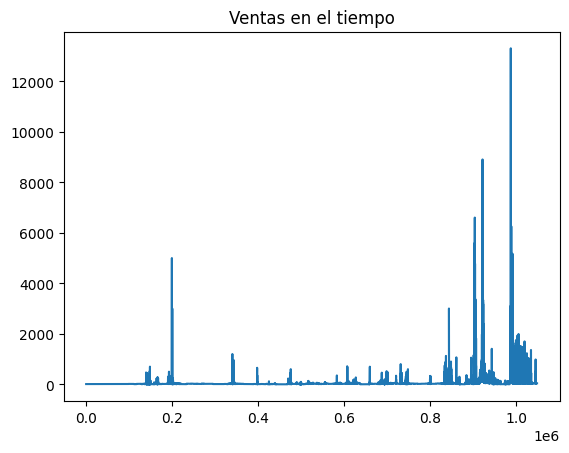

In [20]:
#generamos un grafico para ver outleers y tendencias
df_ventas_finales['venta_total_con_ impuesto_ extraccion'].plot()
plt.title('Ventas en el tiempo')
plt.show()

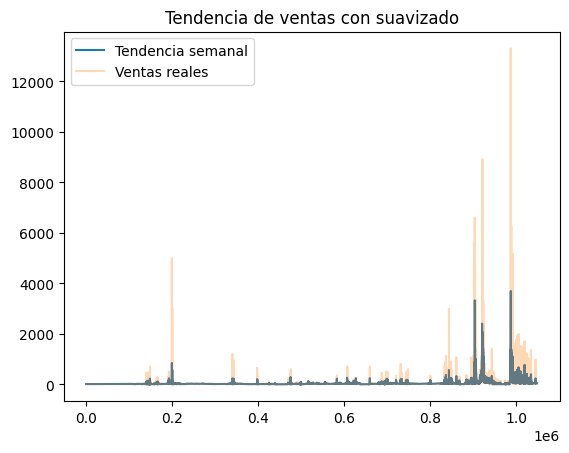

In [21]:
df_ventas_finales['venta_total_con_ impuesto_ extraccion'].rolling(window=7).mean().plot(label='Tendencia semanal')
df_ventas_finales['venta_total_con_ impuesto_ extraccion'].plot(alpha=0.3, label='Ventas reales')
plt.legend()
plt.title('Tendencia de ventas con suavizado')
plt.show()


In [22]:
from scipy.stats import zscore
df_ventas_finales['zscore'] = zscore(df_ventas_finales['venta_total_con_ impuesto_ extraccion'])
outliers = df_ventas_finales[df_ventas_finales['zscore'].abs() > 3]
print("Outliers detectados:")
print(outliers)


Outliers detectados:
         marca_id                   descripcion tamaño  cantidad_vendida  \
139375      90087  ch_mouton_rothschild_12_paui  750ml                 1   
140626      26248              roederer_cristal  750ml                 1   
140645      26248              roederer_cristal  750ml                 1   
140662      26248              roederer_cristal  750ml                 1   
140675      26248              roederer_cristal  750ml                 1   
...           ...                           ...    ...               ...   
1045759     14061  shafer_one_pnt_five_cab_svgn  750ml                 4   
1045767     17932      camp_meeting_ridge_chard  750ml                 4   
1045790     25009  st_supery_dollarhide_cab_svg  750ml                 4   
1045804     36483               tommasi_amarone  750ml                 4   
1045805     36570     flora_springs_trilogy_cal  750ml                 4   

         venta_total  precio_unitario fecha_venta  volumen  clasif

## vamos a utilizar el modelo Prophet ya que nos sirve para series temporales y buscar predicciones de ventas futuras

### 🧠 Paso 1: Preparar los datos

In [25]:

#para el modelo prophet necesitamos un dataframe con dos columnas, ds (fecha) y y (valor a predecir) en este caso va hacer la cantidad de ventas
df = df_ventas_finales[['fecha_venta', 'cantidad_vendida']].rename(columns={'fecha_venta': 'ds', 'cantidad_vendida': 'y'})


### 🔮Entrenamos el modelo y realizamos la predicción

In [26]:
modelo = Prophet()
modelo.fit(df)

14:37:37 - cmdstanpy - INFO - Chain [1] start processing
14:41:09 - cmdstanpy - INFO - Chain [1] done processing


### 📅 Paso 3: Creamos la prediccion de un trismestre(90 dias) ya que las ventas son solo de dos meses

In [27]:
futuro = modelo.make_future_dataframe(periods=90)

### 📈 Paso 4: Generar predicciones

In [28]:
predicciones = modelo.predict(futuro)


### 🎯 Paso 5: Visualizar resultados

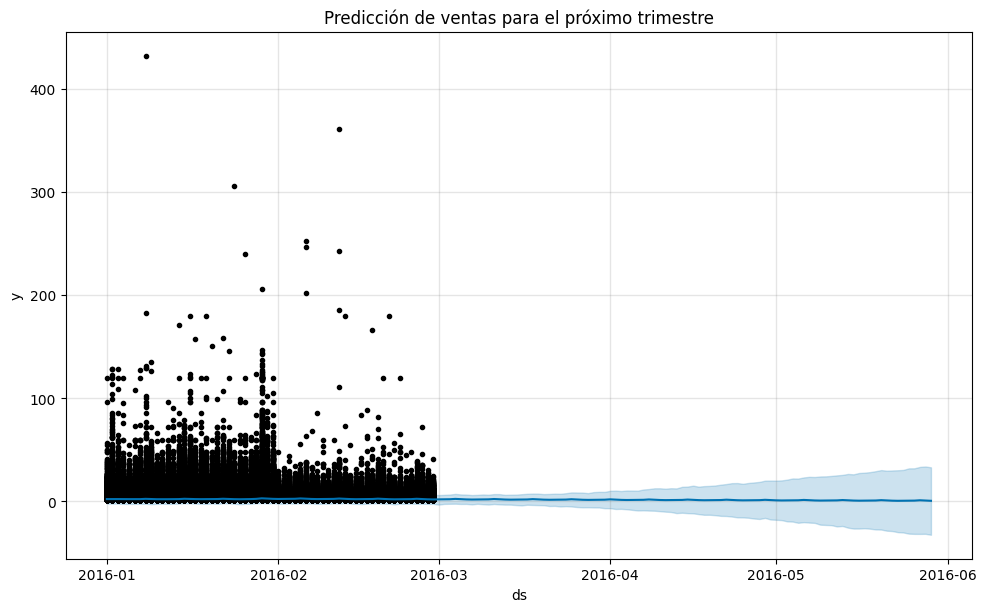

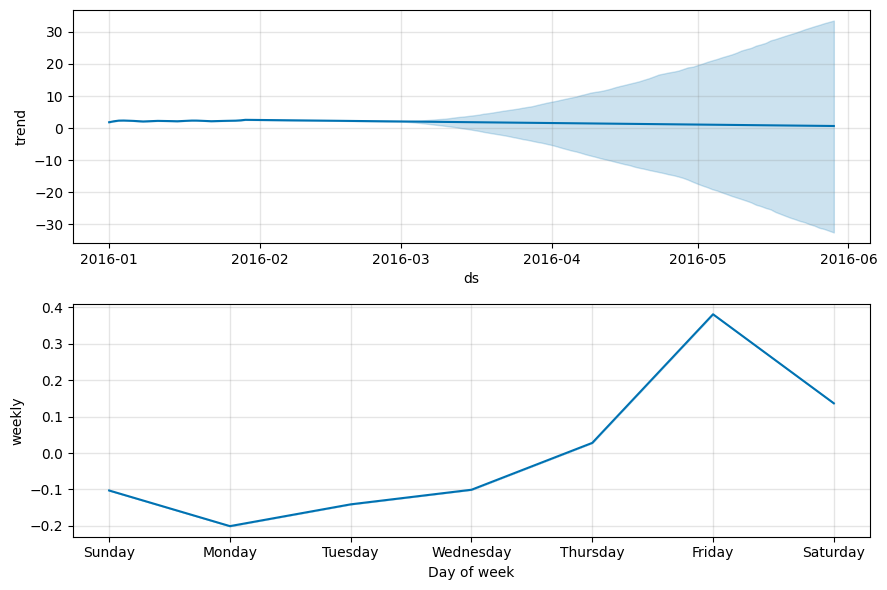

In [29]:
modelo.plot(predicciones)
plt.title('Predicción de ventas para el próximo trimestre')
plt.show()

modelo.plot_components(predicciones)
plt.show()


In [ ]:
import streamlit as st


# Usuario selecciona filtros
producto = st.selectbox("Selecciona producto", df["producto"].unique())
ciudad = st.selectbox("Selecciona ciudad", df["ciudad"].unique())
tienda = st.selectbox("Selecciona tienda", df["tienda"].unique())

# Filtrar los datos
df_filtro = df[(df["producto"] == producto) &
               (df["ciudad"] == ciudad) &
               (df["tienda"] == tienda)][["Fecha_venta","Cantidad_ventas"]]

df_filtro = df_filtro.rename(columns={"Fecha_venta":"ds","Cantidad_ventas":"y"})

# Entrenar Prophet para esa combinación
m = Prophet()
m.fit(df_filtro)

# Predecir próximos 90 días
future = m.make_future_dataframe(periods=90, freq="D")
forecast = m.predict(future)

# Total de ventas esperadas
total = forecast.tail(90)["yhat"].sum()
st.success(f"🔮 Se esperan {total:.0f} ventas en los próximos 3 meses para {producto} - {ciudad} - {tienda}")


MemoryError: Unable to allocate 6.87 GiB for an array with shape (7034, 1048575) and data type bool